# Module 11 Lab: Social Network Analytics

## Objective

In this lab, you will analyse relationships using network thinking.

By the end of this lab, you should be able to:

- represent data as a network
- visualise nodes and connections
- identify important nodes using centrality measures
- interpret network patterns meaningfully

## Why this matters

Some important patterns are not found in individual rows of data.

They are found in:

- who connects with whom
- who acts as a bridge
- who may be isolated
- how interaction flows through a network

Social Network Analytics helps us understand these patterns.

## Scenario

You are given student interaction data from a discussion forum.

Each interaction shows one student replying to another.

Your task is to:

- build the network
- identify important students
- interpret what the structure may mean

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

## Step 1: Load the interaction data

Each row shows a directed interaction:

- `source` → the student initiating the interaction
- `target` → the student receiving the interaction

Look at the data first before building the network.

In [2]:
interaction_data = pd.DataFrame({
    "source": ["A", "A", "B", "B", "C", "D", "E", "F", "G"],
    "target": ["B", "C", "C", "D", "A", "E", "F", "G", "E"]
})

display(interaction_data)

,source,target
0,A,B
1,A,C
2,B,C
3,B,D
4,C,A
5,D,E
6,E,F
7,F,G
8,G,E


## Guided interpretation

Look at the interactions and think about:

- Which students appear frequently?
- Are some students only mentioned once?
- Do any students appear to connect multiple others?

Write a short note in a new markdown cell.

## Step 2: Build the network

We now convert the interaction data into a network.

In this network:

- each student is a **node**
- each interaction is an **edge**

In [3]:
G = nx.from_pandas_edgelist(
    interaction_data,
    source="source",
    target="target",
    create_using=nx.DiGraph()
)

## Step 3: Basic network information

Let us inspect the network structure.

We want to know:

- how many nodes there are
- how many edges there are
- who is in the network

In [4]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))

Number of nodes: 7
Number of edges: 9
Nodes: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
Edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'A'), ('D', 'E'), ('E', 'F'), ('F', 'G'), ('G', 'E')]


## Step 4: Visualise the network

A visual representation helps us see the structure more clearly.

This is often the best first step in network analysis.

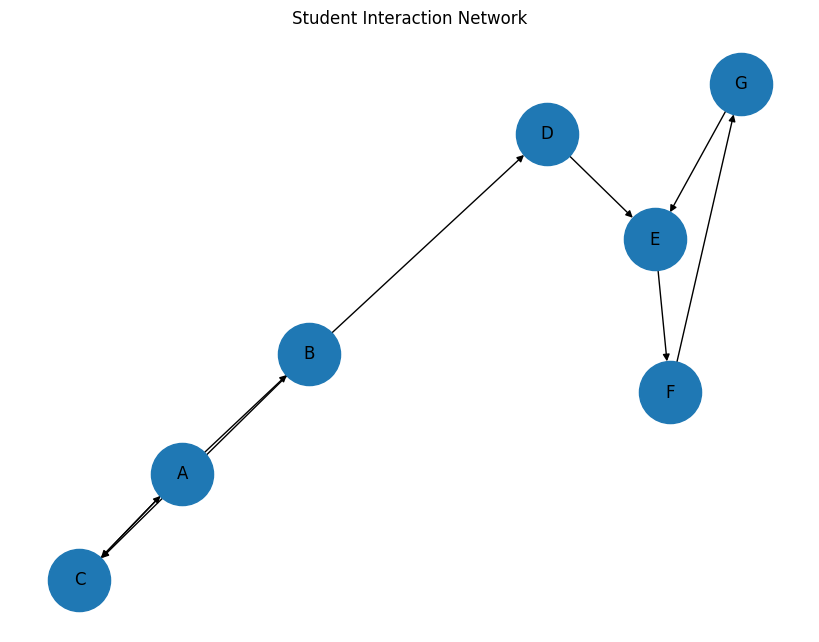

In [5]:
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    arrows=True
)

plt.title("Student Interaction Network")
plt.show()

## Guided interpretation

Look at the network diagram and think about:

- Which students seem more connected?
- Are there any students at the edge of the network?
- Does anyone appear to connect different parts of the network?

Write your observations in a new markdown cell.

## Step 5: Degree centrality

Degree centrality tells us how connected each node is.

For a directed network, we can look at:

- **in-degree** → how many incoming connections a student has
- **out-degree** → how many outgoing connections a student has

In [6]:
in_degree = pd.DataFrame(G.in_degree(), columns=["student", "in_degree"])
out_degree = pd.DataFrame(G.out_degree(), columns=["student", "out_degree"])

degree_summary = pd.merge(in_degree, out_degree, on="student")
display(degree_summary.sort_values(by="in_degree", ascending=False))

,student,in_degree,out_degree
2,C,2,1
4,E,2,1
0,A,1,2
1,B,1,2
3,D,1,1
5,F,1,1
6,G,1,1


## Guided interpretation

Think about:

- Which student receives the most interactions?
- Which student initiates the most interactions?
- What might this mean in a forum setting?

Write a short interpretation in a new markdown cell.

## Step 6: Betweenness centrality

Betweenness centrality tells us how often a node lies between others.

This helps identify **bridges** in the network.

In [7]:
betweenness = nx.betweenness_centrality(G)

betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=["student", "betweenness_centrality"]
).sort_values(by="betweenness_centrality", ascending=False)

display(betweenness_df)

,student,betweenness_centrality
3,D,0.300000
4,E,0.300000
1,B,0.266667
5,F,0.166667
0,A,0.166667
2,C,0.033333
6,G,0.033333


## Guided interpretation

Think about:

- Which student has the highest betweenness centrality?
- Does this student connect different parts of the network?
- Why might this matter?

Write your observations in a new markdown cell.

## Step 7: Closeness centrality

Closeness centrality tells us how close a node is to all others in the network.

This helps identify nodes that can reach others efficiently.

In [8]:
closeness = nx.closeness_centrality(G)

closeness_df = pd.DataFrame(
    closeness.items(),
    columns=["student", "closeness_centrality"]
).sort_values(by="closeness_centrality", ascending=False)

display(closeness_df)

,student,closeness_centrality
4,E,0.461538
5,F,0.352941
2,C,0.333333
6,G,0.285714
3,D,0.250000
1,B,0.222222
0,A,0.222222


## Guided interpretation

Think about:

- Which student has the highest closeness centrality?
- Does this suggest they are well-positioned in the network?
- How is this different from being highly connected?

Write your observations in a new markdown cell.

## Step 8: Optional - Eigenvector centrality

Eigenvector centrality measures importance based on connections to other important nodes.

This is a more advanced measure, but it helps identify influence.

In [9]:
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

eigenvector_df = pd.DataFrame(
    eigenvector.items(),
    columns=["student", "eigenvector_centrality"]
).sort_values(by="eigenvector_centrality", ascending=False)

display(eigenvector_df)

,student,eigenvector_centrality
2,C,0.609163
0,A,0.459843
4,E,0.347137
1,B,0.347125
5,F,0.262049
3,D,0.262037
6,G,0.197818


## Guided interpretation

Think about:

- Which student has high eigenvector centrality?
- Does this mean they are connected to important others?
- How is this different from degree centrality?

Write a short note in a new markdown cell.

## Step 9: Interpret the network as a whole

Now move from metrics to meaning.

Ask:

- Who appears central in the network?
- Who might be bridging groups?
- Is anyone isolated or weakly connected?
- What could this mean in a student engagement context?

## Step 10: Think about real-world use

Network analysis can help us:

- identify highly engaged students
- detect isolated students
- find bridge-builders or connectors
- understand how participation is structured

This can support:

- engagement monitoring
- peer mentoring
- intervention planning

## Final reflection

Write a short summary covering:

### 1. Network structure
What does the network look like?

### 2. Key nodes
Which students appear most central?

### 3. Interpretation
What do the centrality measures suggest?

### 4. Usefulness
How could this analysis support decisions?

### 5. Limitations
What can network analysis not tell us on its own?

## Key takeaway

Social Network Analytics helps us move beyond individual data points.

It helps us understand:

- connections
- influence
- structure

But the results still require careful interpretation.